2026-07-31 11:48:14,502 [INFO] Kích thước tập Train: (1697, 10), Tập Test: (425, 10)
2026-07-31 11:48:14,530 [INFO] Bắt đầu mô phỏng Backtest...



BÁO CÁO HIỆU SUẤT GIAO DỊCH (BACKTEST RESULTS)
- Total Return (AI Strategy)    : -0.20%
- Total Return (Buy & Hold)     : 13.43%
- Sharpe Ratio (AI)             : -1.09
- Max Drawdown (AI)             : 0.20%
- Max Drawdown (Buy & Hold)     : 27.64%
- Win Rate                      : 0.00%
- Total Trades Executed         : 2


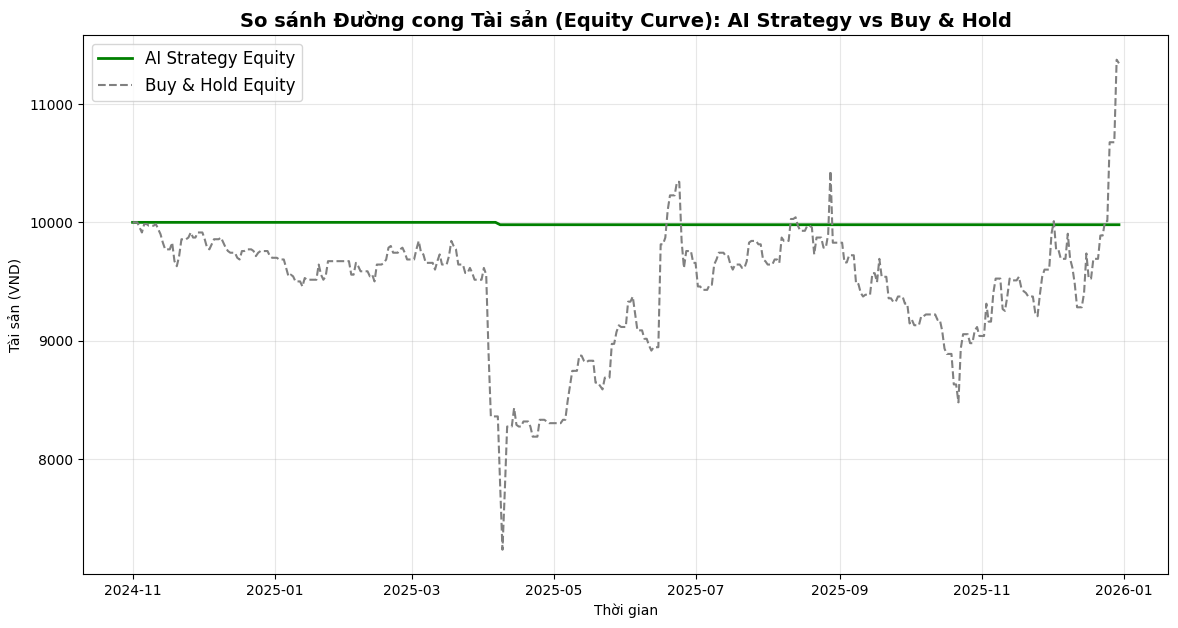

In [ ]:
# Cell 1: Import và Nạp Model + Dữ liệu
import sys
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.model_trainer import ModelTrainer
from utils.backtester import VectorizedBacktester

%load_ext autoreload
%autoreload 2

# Nạp dữ liệu ML-ready và Model đã huấn luyện ở Notebook 07
df_ml = pd.read_parquet("../data/processed/GAS_ml_ready.parquet")
model = joblib.load("../data/processed/xgboost_model.pkl")

# Cell 2: Lấy dữ liệu tập Test (20% thời gian cuối) để chạy Backtest
trainer = ModelTrainer(df_ml, target_col='Target')
X_train, X_test, y_train, y_test = trainer.time_series_split(test_size=0.2)

# Lấy DataFrame ứng với khoảng thời gian tập Test
test_df = df_ml.loc[X_test.index].copy()

# Dự đoán từ Model AI
predictions = model.predict(X_test)

# Cell 3: Chạy Backtest
backtester = VectorizedBacktester(test_df, initial_capital=10000.0, fee_rate=0.001)
df_results = backtester.run_backtest(predictions)
metrics = backtester.evaluate_performance()

# In Báo cáo Hiệu suất Tài chính
print("\n" + "="*60)
print("BÁO CÁO HIỆU SUẤT GIAO DỊCH (BACKTEST RESULTS)")
print("="*60)
for k, v in metrics.items():
    print(f"- {k:<30}: {v}")
print("="*60)

# Cell 4: Trực quan hóa Đường cong Tài sản (Equity Curve)
plt.figure(figsize=(14, 7))
plt.plot(df_results.index, df_results['Equity_AI'], label='AI Strategy Equity', color='green', linewidth=2)
plt.plot(df_results.index, df_results['Equity_BuyHold'], label='Buy & Hold Equity', color='gray', linestyle='--', linewidth=1.5)

plt.title("So sánh Đường cong Tài sản (Equity Curve): AI Strategy vs Buy & Hold", fontsize=14, fontweight="bold")
plt.xlabel("Thời gian")
plt.ylabel("Tài sản (VND)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()